# EDA - Pulso TransMi

Notebook para analizar la serie de demanda de TransMilenio, sus variables contextuales y detectar outliers.

Objetivos:
- Revisar estructura del dataset.
- Identificar la variable objetivo (`demand`).
- Detectar outliers y anomalías.
- Explorar distribuciones y relaciones entre variables.


In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import geopandas as gpd

from pulso_transmi import PulsoTransmiClient

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

client = PulsoTransmiClient()
stations = client.stations()
observations = client.observations_dataframe(page_size=5000)
context = client.context_dataframe(page_size=5000)

print("Estaciones:", stations.shape)
print("Observaciones:", observations.shape)
print("Contexto:", context.shape)
print("")
print(stations.head())
print("")
print(observations.head())
print("")
print(context.head())


Estaciones: (12, 5)
Observaciones: (51840, 3)
Contexto: (4320, 6)

  station_id              station_name   corridor  latitude  longitude
0      03000               Portal Suba       Suba  4.746815 -74.094279
1      05000           Portal Américas   Américas  4.629381 -74.173058
2      09000               Portal Usme    Caracas  4.531715 -74.119391
3      02300  Calle 100 - Marketmedios  Autonorte  4.683947 -74.057696
4      09122                  Calle 72    Caracas  4.658239 -74.062069

                observed_at station_id  demand
0 2026-07-26 05:00:00+00:00      02300      56
1 2026-07-26 05:00:00+00:00      03000      84
2 2026-07-26 05:00:00+00:00      05000     104
3 2026-07-26 05:00:00+00:00      05100     279
4 2026-07-26 05:00:00+00:00      06000     212

                observed_at  rain_mm  rain_forecast  temperature_c  \
0 2026-07-26 05:00:00+00:00      0.0       0.924272       9.470218   
1 2026-07-26 05:15:00+00:00      0.0       0.278162      10.204494   
2 2026-07-26 

## 1) Variables objetivo y estructura

La variable principal es `demand`, que representa la demanda estimada por estación y tiempo.
Entre las variables auxiliares están el clima y eventos en el contexto.

In [7]:
# Crear una vista para análisis por estación
# Unir observaciones con contexto
# y preparar una vista agregada por estación para mapas

df = observations.merge(context, on="observed_at", how="left")
df["date"] = pd.to_datetime(df["observed_at"]).dt.tz_localize(None)

# Agregado por estación: promedio de demanda y variables geográficas
station_summary = (
    df.groupby("station_id", as_index=False)
      .agg(
          avg_demand=("demand", "mean"),
          max_demand=("demand", "max"),
          min_demand=("demand", "min"),
          avg_temp=("temperature_c", "mean"),
          avg_rain=("rain_mm", "mean"),
          avg_event=("event_intensity", "mean"),
      )
      .merge(stations, on="station_id", how="left")
)

numeric_cols = ["demand", "rain_mm", "rain_forecast", "temperature_c", "temperature_forecast", "event_intensity"]

print(df.info())
print("")
print(df.describe(include=[np.number]).round(3))
print("")
print("Distribución por estación:")
print(df.groupby("station_id")["demand"].agg(["mean", "std", "min", "max"]).round(2).head())
print("")

print(station_summary.head())

<class 'pandas.DataFrame'>
RangeIndex: 51840 entries, 0 to 51839
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   observed_at           51840 non-null  datetime64[us, UTC]
 1   station_id            51840 non-null  string             
 2   demand                51840 non-null  int64              
 3   rain_mm               51840 non-null  float64            
 4   rain_forecast         51840 non-null  float64            
 5   temperature_c         51840 non-null  float64            
 6   temperature_forecast  51840 non-null  float64            
 7   event_intensity       51840 non-null  float64            
 8   date                  51840 non-null  datetime64[us]     
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(5), int64(1), string(1)
memory usage: 3.6 MB
None

          demand    rain_mm  rain_forecast  temperature_c  \
count  51840.000  51840.000      51840.

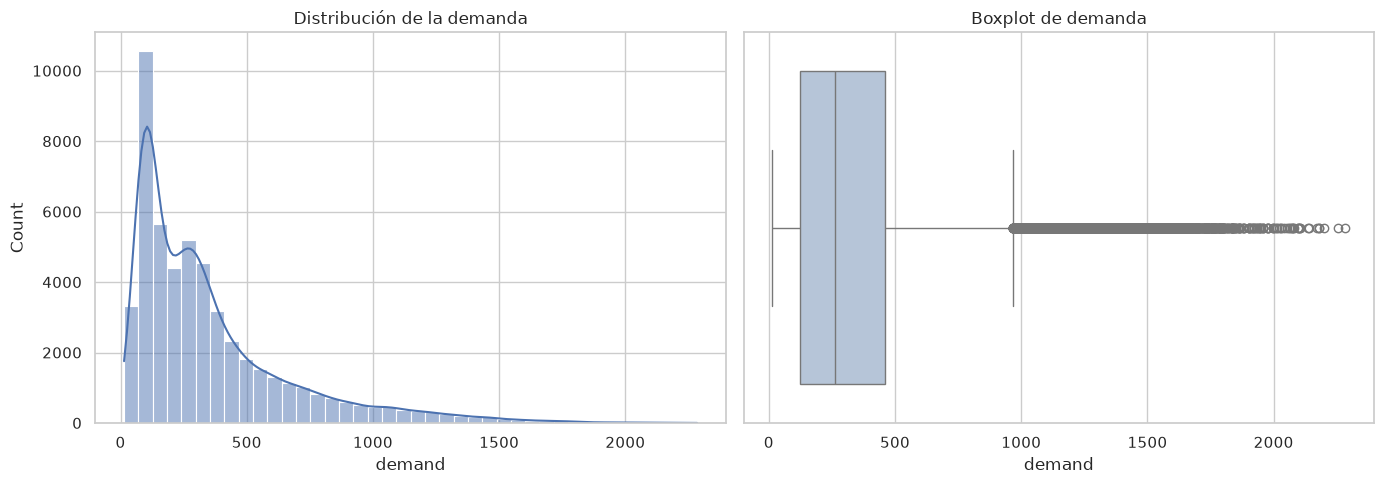

In [8]:
# Histograma de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["demand"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribución de la demanda")
axes[0].set_xlabel("demand")

# Boxplot para detectar outliers
sns.boxplot(x=df["demand"], ax=axes[1], color="lightsteelblue")
axes[1].set_title("Boxplot de demanda")
axes[1].set_xlabel("demand")
plt.tight_layout()
plt.show()


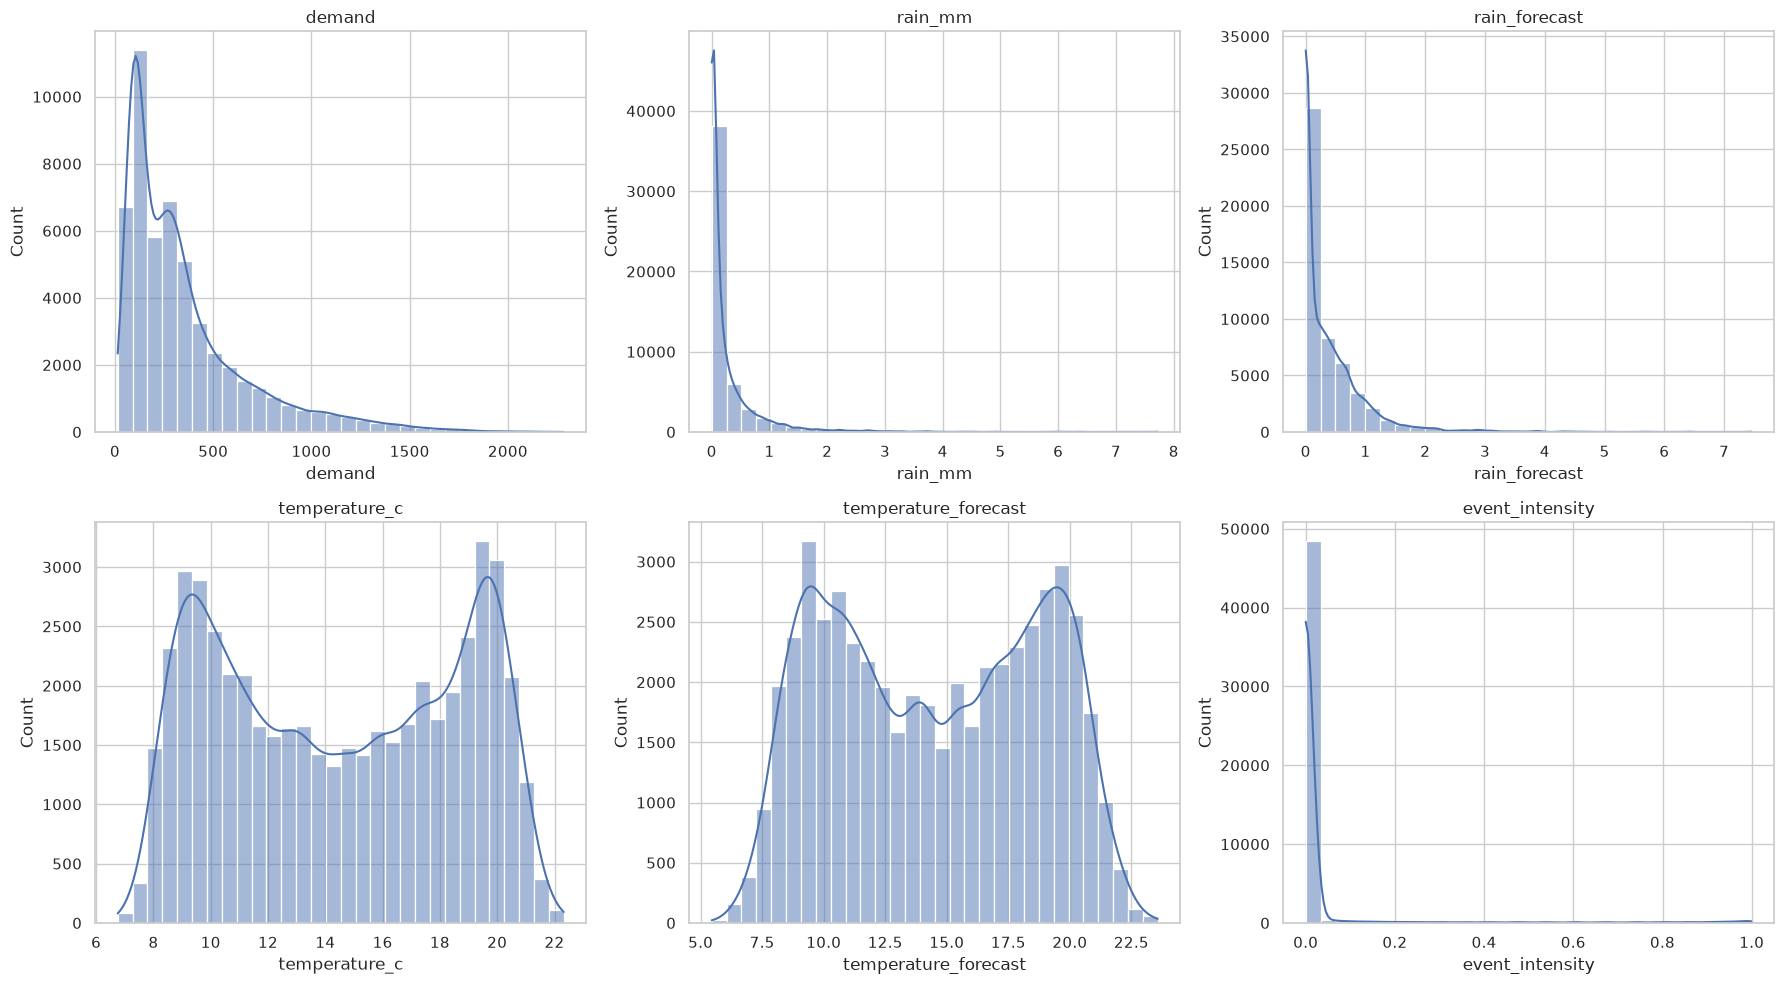

In [9]:
# Distribución de variables contextuales
numeric_cols = ["demand", "rain_mm", "rain_forecast", "temperature_c", "temperature_forecast", "event_intensity"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


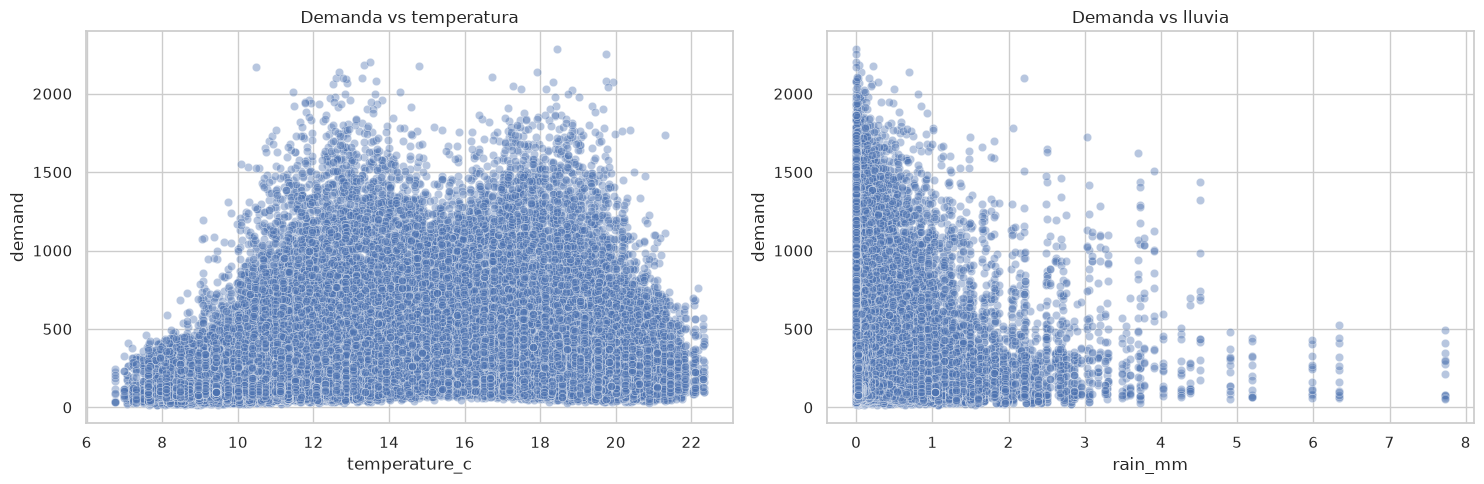

In [10]:
# Scatterplots para detectar relaciones lineales y patrones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df, x="temperature_c", y="demand", alpha=0.4, ax=axes[0])
axes[0].set_title("Demanda vs temperatura")

sns.scatterplot(data=df, x="rain_mm", y="demand", alpha=0.4, ax=axes[1])
axes[1].set_title("Demanda vs lluvia")

plt.tight_layout()
plt.show()


In [11]:
# Detección de outliers por IQR
Q1 = df["demand"].quantile(0.25)
Q3 = df["demand"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["demand"] < lower) | (df["demand"] > upper)]
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Límite inferior={lower:.2f}, límite superior={upper:.2f}")
print(f"Número de outliers: {len(outliers)}")
print(outliers[["station_id", "observed_at", "demand"]].head())


Q1=122.00, Q3=460.00, IQR=338.00
Límite inferior=-385.00, límite superior=967.00
Número de outliers: 3315
    station_id               observed_at  demand
266      05000 2026-07-26 10:30:00+00:00    1010
284      07111 2026-07-26 10:45:00+00:00     977
290      05000 2026-07-26 11:00:00+00:00    1154
296      07111 2026-07-26 11:00:00+00:00    1354
308      07111 2026-07-26 11:15:00+00:00    1142


Promedio de demanda por hora:
hour
0     534.51
1     383.03
2     280.84
3     213.93
4     172.20
5     151.06
6     139.55
7     137.83
8     148.85
9     214.56
10    392.40
11    618.59
12    677.39
13    538.53
14    361.52
15    268.19
16    250.49
17    258.26
18    258.77
19    270.24
20    355.11
21    539.70
22    701.08
23    689.89
Name: avg_demand_hour, dtype: float64

Top 10 estaciones por demanda promedio:
   station_id                            station_name      corridor  \
8       07111                          Ricaurte - NQS           NQS   
3       05100                                Banderas      Américas   
4       06000  Portal El Dorado – C.C. NUESTRO BOGOTÁ      Calle 26   
2       05000                         Portal Américas      Américas   
11      10009                          Museo Nacional  Carrera 7-10   
0       02300                Calle 100 - Marketmedios     Autonorte   
7       07107                    Universidad Nacional           NQS   
6     

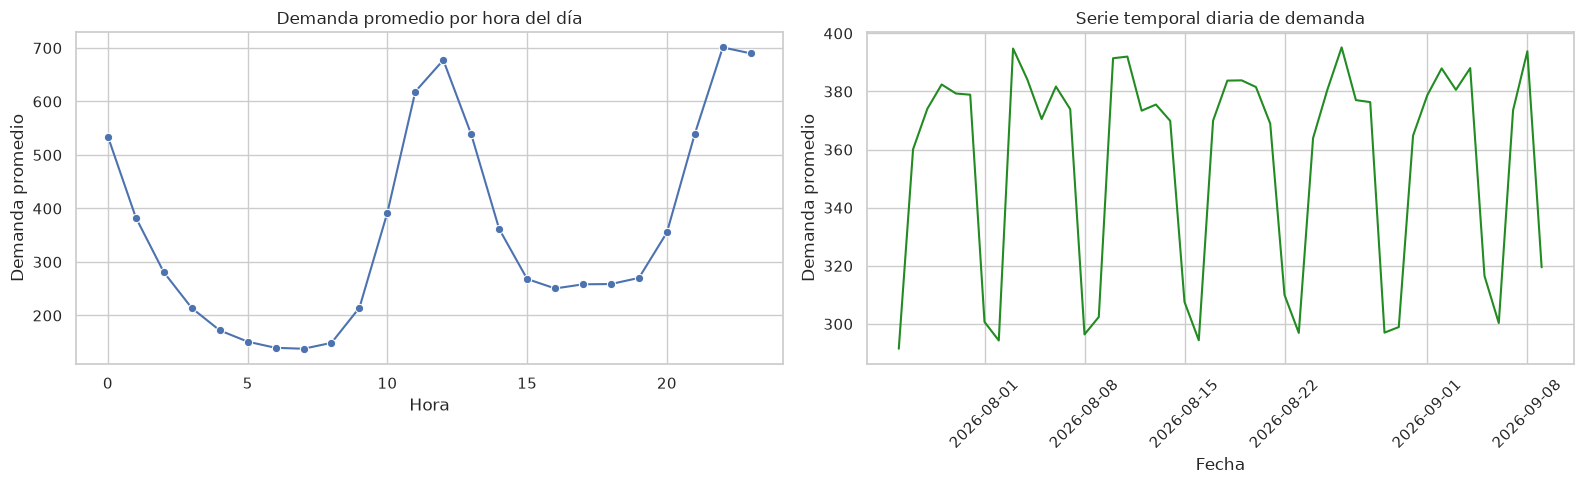

In [12]:
# Análisis temporal: demanda por hora, día y estación

df["hour"] = pd.to_datetime(df["observed_at"]).dt.hour

daily_demand = (
    df.groupby(["date", "station_id"], as_index=False)["demand"]
      .mean()
      .rename(columns={"demand": "avg_demand_day"})
)

hourly_demand = (
    df.groupby(["hour", "station_id"], as_index=False)["demand"]
      .mean()
      .rename(columns={"demand": "avg_demand_hour"})
)

hourly_summary = hourly_demand.groupby("hour")["avg_demand_hour"].mean().sort_index()
print("Promedio de demanda por hora:")
print(hourly_summary.round(2))
print("\nTop 10 estaciones por demanda promedio:")
print(
    station_summary.sort_values("avg_demand", ascending=False)
    [["station_id", "station_name", "corridor", "avg_demand"]]
    .head(10)
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=hourly_summary.reset_index(), x="hour", y="avg_demand_hour", ax=axes[0], marker="o")
axes[0].set_title("Demanda promedio por hora del día")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Demanda promedio")

by_day = df.groupby(pd.to_datetime(df["observed_at"]).dt.date, as_index=False)["demand"].mean()
by_day.columns = ["date", "avg_demand"]
by_day["date"] = pd.to_datetime(by_day["date"])

sns.lineplot(data=by_day, x="date", y="avg_demand", ax=axes[1], color="forestgreen")
axes[1].set_title("Serie temporal diaria de demanda")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Demanda promedio")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


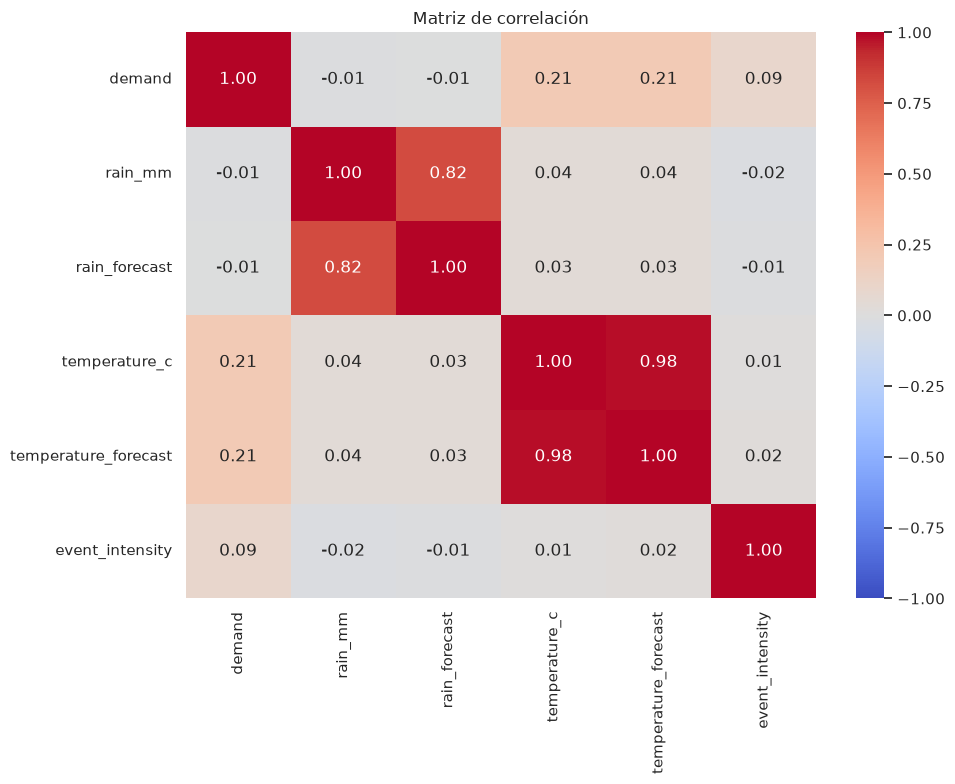

In [13]:
# Correlación entre variables numéricas
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Mapa geográfico con tamaños proporcionales a la demanda promedio
station_map = station_summary.dropna(subset=["latitude", "longitude"]).copy()
station_map["circle_size"] = (station_map["avg_demand"] - station_map["avg_demand"].min()) / (
    station_map["avg_demand"].max() - station_map["avg_demand"].min() + 1e-9
) * 150 + 30

m = folium.Map(location=[4.6, -74.08], zoom_start=11, tiles="OpenStreetMap")
for _, row in station_map.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["circle_size"] / 8,
        popup=f"{row['station_name']}<br>Demanda media: {row['avg_demand']:.1f}",
        color="crimson",
        fill=True,
        fill_opacity=0.7,
        weight=1,
    ).add_to(m)

m


In [14]:
# Análisis geográfico: estaciones con mayor demanda y escala proporcional
station_map = station_summary.dropna(subset=["latitude", "longitude"]).copy()
station_map["radius_scale"] = (
    (station_map["avg_demand"] - station_map["avg_demand"].min())
    / (station_map["avg_demand"].max() - station_map["avg_demand"].min() + 1e-9)
    * 55
    + 10
)

# Mapa público de Bogotá con nodos por estación
m = folium.Map(location=[4.66, -74.09], zoom_start=11, tiles="CartoDB positron")
for _, row in station_map.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["radius_scale"],
        popup=(
            f"<b>{row['station_name']}</b><br>"
            f"Estación: {row['station_id']}<br>"
            f"Corredor: {row['corridor']}<br>"
            f"Demanda media: {row['avg_demand']:.1f}"
        ),
        color="darkred",
        fill=True,
        fill_color="crimson",
        fill_opacity=0.75,
        weight=1.2,
    ).add_to(m)

m

/home/lemonbynon/miniconda3/envs/pulso-transmi/lib/python3.11/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


## 2) Mapa geográfico y análisis espacial

Ahora incorporamos la ubicación real de las estaciones para visualizar dónde está la mayor demanda y cómo se distribuye geográficamente. Los círculos más grandes indican mayor demanda promedio.

### ¿Qué vemos?
- Las estaciones del centro o corredores más densos suelen tener mayor demanda.
- Se pueden detectar zonas con mayor concentración de carga.
- La ubicación geográfica ayuda a interpretar causas de demanda por corredor o barrio.

### Siguientes pasos
- Generar mapas por hora o por día de la semana.
- Comparar demanda promedio y p95 por estación.
- Unir con variables climáticas para estudiar patrones espaciales.


In [16]:
# Mapa geográfico con tamaños proporcionales a la demanda promedio
station_map = station_summary.dropna(subset=["latitude", "longitude"]).copy()
station_map["circle_size"] = (
    (station_map["avg_demand"] - station_map["avg_demand"].min())
    / (station_map["avg_demand"].max() - station_map["avg_demand"].min() + 1e-9)
    * 150 + 30
)

m = folium.Map(location=[4.6, -74.08], zoom_start=11, tiles="OpenStreetMap")
for _, row in station_map.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["circle_size"] / 8,
        popup=f"{row['station_name']}<br>Demanda media: {row['avg_demand']:.1f}",
        color="crimson",
        fill=True,
        fill_opacity=0.7,
        weight=1,
    ).add_to(m)

m


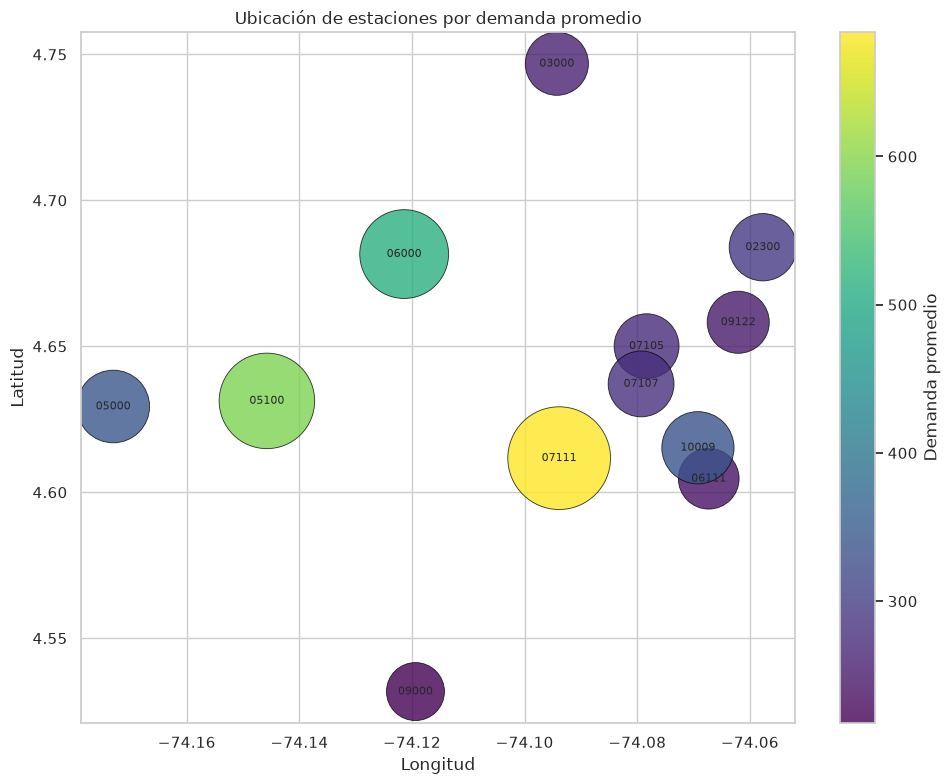

In [17]:
# Mapa de calor de estaciones por demanda promedio
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    station_map["longitude"],
    station_map["latitude"],
    s=station_map["avg_demand"] * 8,
    c=station_map["avg_demand"],
    cmap="viridis",
    alpha=0.8,
    edgecolors="black",
    linewidths=0.6,
)
for _, row in station_map.iterrows():
    ax.text(row["longitude"], row["latitude"], row["station_id"], fontsize=8, ha="center", va="center")

ax.set_title("Ubicación de estaciones por demanda promedio")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
fig.colorbar(sc, ax=ax, label="Demanda promedio")
plt.tight_layout()
plt.show()


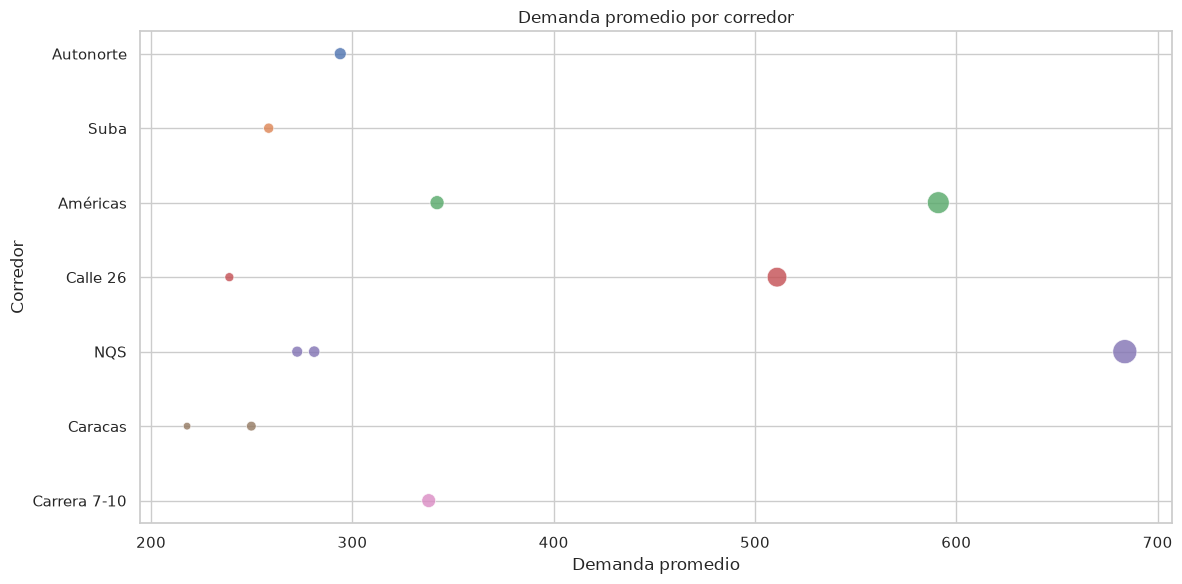

In [18]:
# Gráfico de dispersión por corredor
if "corridor" in station_map.columns:
    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=station_map,
        x="avg_demand",
        y="corridor",
        size="avg_demand",
        sizes=(30, 300),
        hue="corridor",
        legend=False,
        alpha=0.8,
    )
    plt.title("Demanda promedio por corredor")
    plt.xlabel("Demanda promedio")
    plt.ylabel("Corredor")
    plt.tight_layout()
    plt.show()


## 3) Hallazgos esperados

- La variable objetivo `demand` suele mostrar asimetría y valores atípicos.
- La lluvia y los eventos pueden influir en la demanda de manera no lineal.
- El análisis por estación permite detectar diferencias de comportamiento entre distintas zonas del sistema.
- Los outliers deben revisarse antes de entrenar modelos para evitar ruido extremo.
- Las estaciones con mayor demanda tienden a concentrarse en zonas geográficas específicas.

### Siguientes pasos
- Crear features temporales (hora, día de la semana, mes).
- Agregar en un dataframe final con estación + fecha + contexto.
- Preparar una línea base de regresión o serie de tiempo.
